### Import libraries and files

In [ ]:
# ##########################################################################
# # !pip uninstall open3d -y
# !conda install open3d -c conda-forge -y
# # !conda install open3d=0.18.0 -c conda-forge -y
# import open3d as o3d
# print("DONE")
# ##########################################################################

In [ ]:
##########################################################################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.offline import plot
from matplotlib import cm
from scipy.interpolate import griddata
##########################################################################
# AI driven imports
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
##########################################################################
# Config Parameters
current_folder = str(globals()['_dh'][0]) + '/Data/SurfacePlotTests'
analysis       = ['IMPERFECTION', 'THICKNESS'][0]
geometry       = ['CYLINDER', 'SPHERICAL_HEAD', 'CIRCULAR_FLAT_PLATE', 'PIPE_ELBOW'][0]
##########################################################################
# File routing
data_map = {
    'IMPERFECTION': {
        'CYLINDER':           'testCylImperfection.csv',
        'SPHERICAL_HEAD':     'testSphImperfection.csv',
        'CIRCULAR_FLAT_PLATE':'testFlatImperfection.csv',
        'PIPE_ELBOW':         'testPipeImperfection.csv',
    },
    'THICKNESS': {
        'CYLINDER':           'testCylThickness.csv',
        'SPHERICAL_HEAD':     'testSphThickness.csv',
        'CIRCULAR_FLAT_PLATE':'testFlatThickness.csv',
        'PIPE_ELBOW':         'testPipeThickness.csv',
    }
}
##########################################################################
# Load data
npDataIn      = pd.read_csv(current_folder + "/" + data_map[analysis][geometry]).values
##########################################################################
x, y, z, t  = npDataIn[:, 1], npDataIn[:, 2], npDataIn[:, 3], npDataIn[:, 4]
t_rgb       = np.vstack([t, t, t]).T
point_cloud = np.vstack([x, y, z]).T
##########################################################################
print('Input Data Shape     : ', npDataIn.shape)
print('Point Cloud Shape (1): ', point_cloud.shape)
print("Done")
##########################################################################

### Functions Used

In [12]:
##########################################################################
def fill_nan(A_val=[]):
    ''' Interpolate to fill nan values '''
    A = A_val
    ok = ~np.isnan(A)
    xp = ok.ravel().nonzero()[0]
    fp = A[~np.isnan(A)]
    x  = np.isnan(A).ravel().nonzero()[0]
    A[np.isnan(A)] = np.interp(x, xp, fp)
    return A

##########################################################################
def map_z2colorVAL(zval=[], vmin=0, vmax=1, normalize=False):
    """
    Map the (normalized) value zval to a corresponding color in the colormap
    if vmin>vmax: raise ValueError('incorrect relation between vmin and vmax')
    """
    if normalize:
        t = (zval - vmin) / float((vmax - vmin))
    else:
        t = zval
    return t

##########################################################################
def map_z2colorRGB(zval=[], colormap='', vmin=0, vmax=1):
    """
    Map the normalized value zval to a corresponding color in the colormap
    if vmin>vmax: raise ValueError('incorrect relation between vmin and vmax')
    """
    t = (zval-vmin)/float((vmax-vmin)) # normalize val
    R, G, B, alpha=colormap(t)
    val = 'rgb('+'{:d}'.format(int(R*255+0.5))+','+'{:d}'.format(int(G*255+0.5))+ ','+'{:d}'.format(int(B*255+0.5))+')'
    return val
##########################################################################

### Open3D Approach

TriangleMesh with 2914 points and 3824 triangles.
Z Org: 2914 -0.0 30.0
Z New: 2914 -0.037 30.022


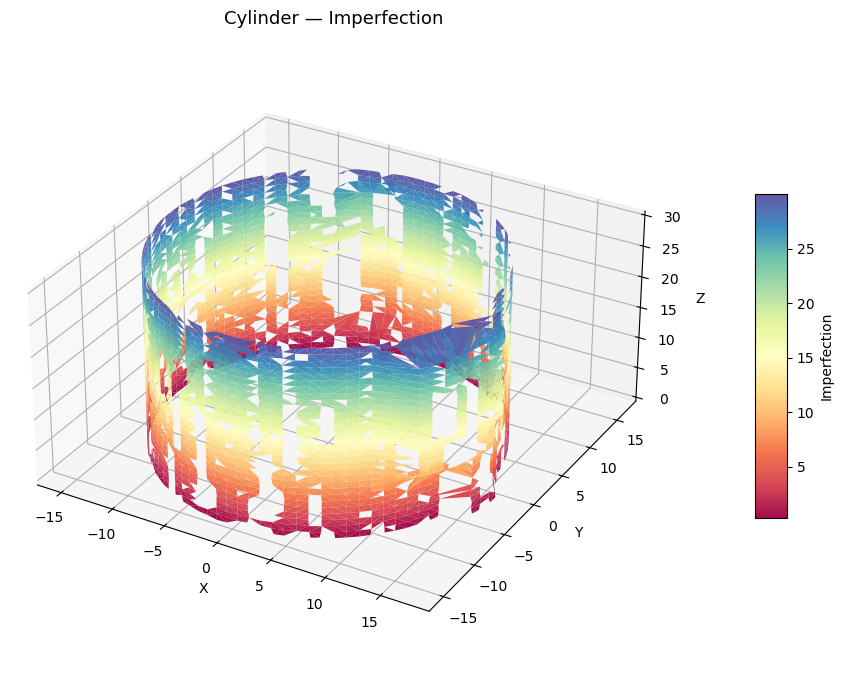

In [13]:
##############################################################################
try:
    ##########################################################################
    # Point Cloud Setup
    pcd        = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(point_cloud[:, :3])
    pcd.colors = o3d.utility.Vector3dVector(t_rgb)
    pcd.estimate_normals()
    if geometry == 'CIRCULAR_FLAT_PLATE':
        pcd.orient_normals_to_align_with_direction()
    else:
        pcd.orient_normals_consistent_tangent_plane(100)
    ##########################################################################
    # Ball-pivoting mesh reconstruction
    distances = pcd.compute_nearest_neighbor_distance()
    avg_dist  = np.mean(distances)
    radius    = avg_dist
    radii     = [r * radius for r in [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 1, 3, 5]]
    rec_mesh  = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(pcd, o3d.utility.DoubleVector(radii))
    ##########################################################################
    # Mesh Cleanup
    rec_mesh = (rec_mesh
        .compute_vertex_normals()
        .remove_degenerate_triangles()
        .remove_duplicated_triangles()
        .remove_duplicated_vertices()
        .remove_non_manifold_edges()
        .filter_smooth_taubin(number_of_iterations=1, filter_scope=o3d.geometry.FilterScope.All)
    )
    print(rec_mesh)
    ##########################################################################
    # Extract Vertices
    triangles = np.asarray(rec_mesh.triangles)
    vertices  = np.asarray(rec_mesh.vertices)
    xInterp   = vertices[:, 0]
    yInterp   = vertices[:, 1]
    zInterp   = vertices[:, 2]
    tInterp   = np.asarray(rec_mesh.vertex_colors)[:, 0]
    if np.count_nonzero(np.isnan(zInterp)) > 0:
        xInterp = fill_nan(A_val=xInterp)
        yInterp = fill_nan(A_val=yInterp)
        zInterp = fill_nan(A_val=zInterp)
    print('Z Org:', z.shape[0],      round(z.min(), 3),       round(z.max(), 3))
    print('Z New:', zInterp.shape[0], round(zInterp.min(), 3), round(zInterp.max(), 3))
    ##########################################################################
    # this line is commented out due to not working in Jupyter Notebook
    # it is meant to help view and interact with the produced 3D plot below
    # o3d.visualization.draw_geometries([pcd, rec_mesh], point_show_normal=True)
    ##########################################################################
    # Produce 3D Plot
    fig  = plt.figure(figsize=(10, 7))
    ax   = fig.add_subplot(1, 1, 1, projection='3d')
    surf = ax.plot_trisurf(xInterp, yInterp, zInterp, triangles=triangles,cmap=plt.cm.Spectral, linewidth=0, antialiased=True, alpha=0.95)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1, label=Analysis.capitalize())
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'{geometry.replace("_", " ").title()} — {Analysis.capitalize()}', fontsize=13)
    ax.set_box_aspect([1, 1, 0.5])
    if geometry == 'CIRCULAR_FLAT_PLATE':
        z_range = max(zInterp.max() - zInterp.min(), 1e-3)
        z_mid   = (zInterp.max() + zInterp.min()) / 2
        ax.set_zlim([z_mid - z_range * 1.5, z_mid + z_range * 1.5])
    plt.tight_layout()
    plt.show()
    ##########################################################################
except:
    print("Skipped Installing Open3D for this run")
##############################################################################

### Plotly Approach

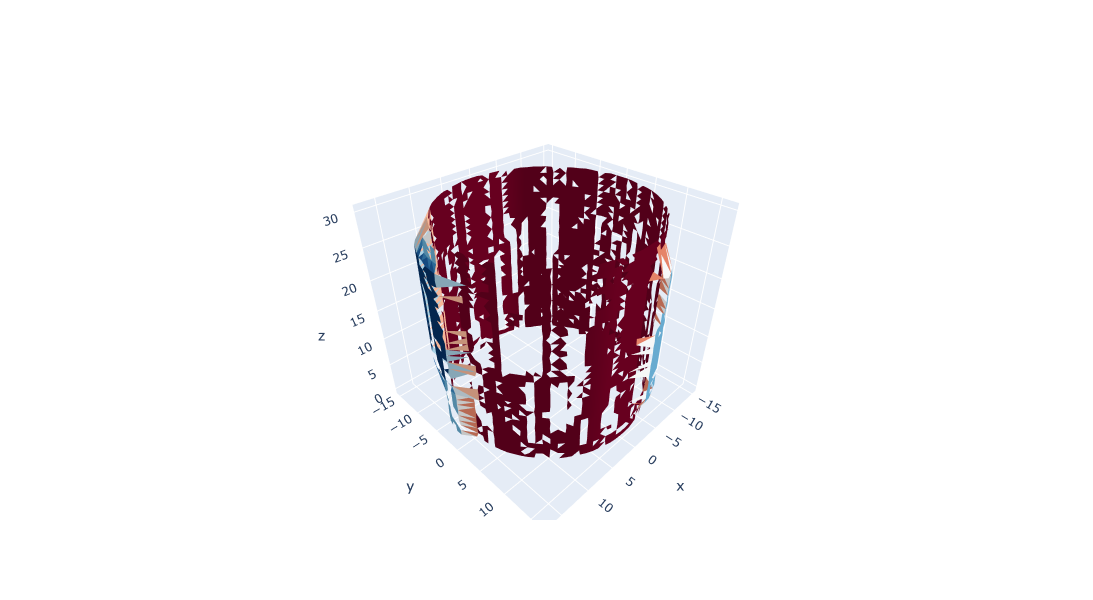

In [28]:
##############################################################################
if t.shape[0] == xInterp.shape[0]:
    points3D = np.vstack((xInterp, yInterp, zInterp, t)).T
else:
    t_interp0 = griddata(np.vstack([x, y, z]).T, t, np.vstack([xInterp, yInterp, zInterp]).T, method='nearest')
    points3D = np.vstack((xInterp, yInterp, zInterp, t_interp0)).T
##########################################################################
I, J, K = triangles.T
tri_vertices = [points3D[idx] for idx in triangles]  # Vertices of the surface triangles
zmean        = [np.mean(tri[:, 3]) for tri in tri_vertices] # Mean values of target value of triangle vertices
min_zmean, max_zmean = np.min(zmean), np.max(zmean)
facecolor    = [map_z2colorRGB(zval=zz, colormap=cm.RdBu, vmin=min_zmean, vmax=max_zmean) for zz in zmean]
tVal         = [map_z2colorVAL(zval=zz, vmin=min_zmean, vmax=max_zmean, normalize=False)  for zz in zmean]
##########################################################################
mesh         = go.Mesh3d(x=xInterp, y=yInterp, z=zInterp, facecolor=facecolor, i=I, j=J, k=K, name='')
layout       = go.Layout(showlegend=False, height=600, width=600)
fig          = go.Figure(data=mesh, layout=layout)
if geometry == 'CIRCULAR_FLAT_PLATE':
    z_range = max(zInterp.max() - zInterp.min(), 1e-3)
    z_mid   = (zInterp.max() + zInterp.min()) / 2
    fig.update_layout(scene=dict(zaxis=dict(range=[z_mid - z_range * 1.5, z_mid + z_range * 1.5])))
##########################################################################
fig.for_each_trace(lambda t: t.update(visible=False) if isinstance(t, go.Scatter3d) and t.mode == "lines" else t)
fig.show()
##########################################################################

### Now let's take this further, and deploy Point Cloud Deep Learning to predict t from x, y, and z

In [ ]:
# --- Data prep ---
X = point_cloud[:, :3]          # (N, 3) — x, y, z
y = t.reshape(-1, 1)            # (N, 1) — imperfection or thickness

scaler_X = MinMaxScaler().fit(X)
scaler_y = MinMaxScaler().fit(y)
X_scaled  = scaler_X.transform(X)
y_scaled  = scaler_y.transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# Add point dimension for shared MLP: (N, 1, 3)
X_train = X_train[:, np.newaxis, :]
X_test  = X_test[:, np.newaxis, :]

# --- PointNet-inspired regression model ---
def build_pointnet_regression(input_dim=3):
    inputs = tf.keras.Input(shape=(1, input_dim))

    # Shared MLP (applied point-wise via Conv1D)
    x = layers.Conv1D(64,  1, activation='relu')(inputs)
    x = layers.Conv1D(128, 1, activation='relu')(x)
    x = layers.Conv1D(256, 1, activation='relu')(x)

    # Global feature aggregation
    x = layers.GlobalMaxPooling1D()(x)

    # Regression head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64,  activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='linear')(x)

    return Model(inputs, output, name='PointNet_Regression')

model = build_pointnet_regression()
model.summary()

# --- Train ---
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

# --- Evaluate ---
y_pred_scaled = model.predict(X_test)
y_pred        = scaler_y.inverse_transform(y_pred_scaled)
y_true        = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae  = np.mean(np.abs(y_true - y_pred))
r2   = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)

print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R²:   {r2:.4f}')

# --- Training curve ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],     label='Train'); ax1.plot(history.history['val_loss'],     label='Val')
ax2.plot(history.history['mae'],      label='Train'); ax2.plot(history.history['val_mae'],      label='Val')
ax1.set_title('Loss (MSE)'); ax2.set_title('MAE')
for ax in (ax1, ax2):
    ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout()
plt.show()

# --- Predicted vs actual ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true, y_pred, alpha=0.4, edgecolors='k', linewidths=0.3)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title(f'PointNet Regression — {geometry.replace("_", " ").title()}')
plt.tight_layout()
plt.show()